# 第13章：横截面量价策略

同一个月末，过去涨得多、波动小或换手低的股票，下一期表现有什么不同？本章把第12章的“市值排序”换成量价信号，保留相同的月度买入持有方法。

**学习顺序：问题 → 数据与信号计算 → 同池分组 → 输出解释 → 练习。** 不预设任何策略有效，也不把历史赢家当成投资建议。

## 1. 先把实验规则写下来

- 唯一行情输入是第11章 `data/stock_daily.parquet`，只读引用，不复制或重新合并。
- 月末倒数第二个市场交易日收盘形成信号，最后一个交易日收盘建立等权组合；从下一交易日计算收益，月内权重自然漂移。
- 短窗口20日；长窗口120日且跳过最近20日；波动60日；日换手率取20日均值。全部按市场交易日计数。
- 指标用共同有效股票池比较；信号日要求正常交易状态及有效价格、市值；不根据未来收益或未来是否存续筛选。
- 2025-01-01之前是开发段，之后是时间留出段。方向、窗口、等权合成规则在展示结果前固定，不按留出结果选择最佳版本。
- 这是回顾性教学切分。该历史已在课程其他章节使用，不能证明从未被查看；只有后续真正未查看的新数据才能提供更独立的验证。
- 不计交易成本、涨跌停或停牌成交约束。退市后最后价格延续会遗漏实际清算损失；本地数据覆盖也未证明无幸存者偏差。结论限于此理想化样本。

In [1]:
from pathlib import Path
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "Chapter11 - 股票日频收益率分析/data/stock_daily.parquet").is_file())
CHAPTER = ROOT / "Chapter13 - 横截面量价策略"
SOURCE = ROOT / "Chapter11 - 股票日频收益率分析/data/stock_daily.parquet"
TABLES = CHAPTER / "outputs/tables"
FIGURES = CHAPTER / "latex/figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
SHORT, LONG, SKIP, VOL, TURN = 20, 120, 20, 60, 20
MIN_LONG, MIN_VOL, MIN_TURN = 100, 50, 15
SPLIT = pd.Timestamp("2025-01-01")
GROUPS = ["G1", "G2", "G3", "G4", "G5"]
BOARD = [1, 4, 16, 32, 64]
fonts = {f.name for f in font_manager.fontManager.ttflist}
font = next((f for f in ["Microsoft YaHei", "PingFang SC", "SimHei"] if f in fonts), "DejaVu Sans")
plt.rcParams.update({"font.family": font, "axes.unicode_minus": False,
                     "figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
print("Python / pandas:", platform.python_version(), pd.__version__)
print("来源：", SOURCE.relative_to(ROOT))

Python / pandas: 3.11.15 2.3.3
来源： Chapter11 - 股票日频收益率分析\data\stock_daily.parquet


## 2. 一行数据是什么？

一行是某只股票在某日期的记录。`Stkcd`为代码，`Trddt`为日期；仅保留沪深京A股市场类型。

| 字段 | 单位与用途 |
|---|---|
| `Adjprcwd` | 含现金红利再投资的可比价格，价格比值用于收益与持仓估值 |
| `Clsprc` | 未复权收盘价，元/股，用于反推流通股数 |
| `Dnshrtrd` | 当日成交股数，股；真实零成交与缺失记录不同 |
| `Dsmvosd` | 流通市值，千元；先乘1000换成元 |
| `Dsmvtl2` | 总股数乘A股价格的总市值2，千元；用于描述规模暴露 |
| `Trdsta / Filling` | 正常状态为1；非填充记录为0 |

来源为第11章本地CSMAR授权数据，字段口径已对照原包说明。日期覆盖不等于每只股票都有完整历史。

In [3]:
columns = ["Stkcd", "Trddt", "Markettype", "Trdsta", "Filling", "Adjprcwd",
           "Clsprc", "Dnshrtrd", "Dsmvosd", "Dsmvtl2"]
raw = pd.read_parquet(SOURCE, columns=columns)
raw["Stkcd"] = raw.Stkcd.astype("string").str.zfill(6)
assert raw[["Stkcd", "Trddt"]].notna().all().all()
assert not raw.duplicated(["Stkcd", "Trddt"]).any()
source_rows = len(raw)
data = raw.loc[raw.Markettype.isin(BOARD)].copy()
calendar = pd.DatetimeIndex(sorted(data.loc[data.Filling.eq(0) & data.Dnshrtrd.gt(0), "Trddt"].unique()))
print(f"源文件{source_rows:,}行；A股{len(data):,}行；市场交易日{len(calendar)}天")
print(f"日期：{calendar[0]:%Y-%m-%d} 至 {calendar[-1]:%Y-%m-%d}")
display(data.loc[data.Filling.eq(0), columns[:2] + columns[5:]].head().round(4))
del raw

源文件6,888,585行；A股6,778,694行；市场交易日1210天
日期：2021-08-16 至 2026-08-13


,Stkcd,Trddt,Adjprcwd,Clsprc,Dnshrtrd,Dsmvosd,Dsmvtl2
0,000001,2021-08-16,3015.6355,19.95,62705022,3.871448e+08,3.871481e+08
1,000001,2021-08-17,2973.3111,19.67,47602194,3.817112e+08,3.817144e+08
2,000001,2021-08-18,3116.9131,20.62,133273216,4.001467e+08,4.001500e+08
3,000001,2021-08-19,3074.5885,20.34,64997561,3.947130e+08,3.947164e+08
4,000001,2021-08-20,2935.5218,19.42,161462793,3.768598e+08,3.768629e+08


### 2.1 估值可填充，波动与换手不能随意填零

第12章用过去最后有效价格估值，本章保持相同口径。另保留未填充价格矩阵：只有相邻两个市场交易日都有实际正价格，才计算用于波动的日收益，避免将缺失日填成零收益后误判为低风险。

长信号要求最近120日至少100次实际价格观测；波动要求60日至少50个有效日收益；换手要求20日至少15个有效观测。缺失不会自动记为零。首次可用历史不足的股票暂不参加共同股票池。

In [4]:
actual = data.loc[data.Filling.eq(0)].copy()
actual["Adjprcwd"] = actual.Adjprcwd.where(np.isfinite(actual.Adjprcwd) & actual.Adjprcwd.gt(0))
observed = actual.pivot(index="Trddt", columns="Stkcd", values="Adjprcwd").reindex(calendar)
prices = observed.ffill()
daily_observed = observed.pct_change(fill_method=None)
history_count = observed.notna().rolling(LONG, min_periods=LONG).sum()
display(prices.iloc[:4, :4])

Stkcd,000001,000002,000004,000005
2021-08-16,3015.635523,2779.942892,83.322209,21.162805
2021-08-17,2973.311078,2799.316314,84.341239,21.367280
2021-08-18,3116.913083,2871.964171,83.322228,21.265038
2021-08-19,3074.588521,2802.950872,82.616739,20.958332


## 3. 动量与反转：窗口决定我们问的问题

设信号日为 $s$，$P_s$ 是含红利可比价格：

- 短期收益 $R_{20,s}=P_s/P_{s-20}-1$。追随高收益端是短期动量假设；关注低收益端是短期反转假设。同一排序，两种解读。
- 跳月长窗口 $M_s=P_{s-20}/P_{s-120}-1$，累计100个交易日收益，排除最近20日。`shift(20)`将20个交易日前的价格放到当前行。
- 经典动量常使用过去第2—12个月收益；本章120/20是缩短后的教学窗口，不是经典定义，也不复制标准Mom因子的规模交叉分组。

方法参考：[Kenneth French 动量说明](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/det_mom_factor_daily.html)。该网页是方法来源，A股输入来自本地文件。

In [5]:
short_return = prices / prices.shift(SHORT) - 1
long_momentum = prices.shift(SKIP) / prices.shift(LONG) - 1
toy = pd.Series([100.0, 120.0, 108.0], index=["s-120", "s-20", "s"])
print(f"较长窗口：{toy.iloc[1] / toy.iloc[0] - 1:.0%}")
print(f"最近窗口：{toy.iloc[2] / toy.iloc[1] - 1:.0%}")

较长窗口：20%
最近窗口：-10%


例子中较长窗口为20%，最近窗口为−10%。同一只股票可以“此前强、最近弱”，不能将不同窗口的排名混为一谈。

## 4. 低波动：低风险信号是否带来低风险组合？

用过去60个市场交易日内有效日收益的样本标准差乘 $\sqrt{252}$，得到近似年化波动率。50个有效值是最低要求，不足则缺失。波动率越低，低波动评分越高，因此评分取负号。

个股历史波动小，不保证未来组合回撤小；相关性、持仓集中和环境变化都可能改变结果。

In [6]:
volatility = daily_observed.rolling(VOL, min_periods=MIN_VOL).std(ddof=1) * np.sqrt(252)
low_vol_score = -volatility
print("波动率单位为比例；0.30表示年化30%，不是日收益30%。")

波动率单位为比例；0.30表示年化30%，不是日收益30%。


## 5. 换手率：成交股数除以什么？

日换手率表示当日成交股数占流通股数的比例。本包未直接使用流通股数字段，先反推：

$$N^{float}=\frac{Dsmvosd\times1000}{Clsprc},\qquad Turn=\frac{Dnshrtrd\times Clsprc}{Dsmvosd\times1000}.$$

必须使用**未复权价格**与同日市值。若用含红利可比价格，会改变股数分母。取过去20日换手率均值；低换手取负号只是待检验的方向，不代表低换手必然优越或交易容易。

这是**个股交易活跃度**；第12章组合换手是**调仓时权重变化**，两者不能互相代替。

In [7]:
valid_turn = (actual.Clsprc.gt(0) & actual.Dsmvosd.gt(0) & actual.Dnshrtrd.ge(0)
              & np.isfinite(actual.Clsprc) & np.isfinite(actual.Dsmvosd))
actual["turnover"] = (actual.Dnshrtrd * actual.Clsprc / (actual.Dsmvosd * 1000)).where(valid_turn)
turn_daily = actual.pivot(index="Trddt", columns="Stkcd", values="turnover").reindex(calendar)
turnover_mean = turn_daily.rolling(TURN, min_periods=MIN_TURN).mean()
print(f"100万股成交、10元收盘、20万千元流通市值：{1_000_000 * 10 / (200_000 * 1000):.1%}")

100万股成交、10元收盘、20万千元流通市值：5.0%


## 6. 同一天、同一股票池，再合成排名

先生成月末日历，排除文件最后一个不完整月份的建仓；末期仍持有到文件末日。过去120日价格基点尚未出现的月份只用于预热。信号日先检查正常状态、非填充记录、正市值与历史价格，再要求四个原始指标均有效。

共同股票池使策略收益差不被不同缺失样本直接混淆，但会偏向历史较长、记录较完整的股票。每期保存筛选数量。

三个合成方向固定为：较长动量高、波动低、换手低。先在共同池内分别做百分位排名（从小到大的名次除以股票数，并列取平均名次），再等权平均；不混入与20日动量相反的反转信号，也不凭测试结果调权重。

In [8]:
rows = []
for month, dates in pd.Series(calendar, index=calendar).groupby(calendar.to_period("M")):
    if month == calendar[-1].to_period("M"):
        continue
    signal, execution = dates.iloc[-2], dates.iloc[-1]
    if calendar.get_loc(signal) >= LONG:
        rows.append({"signal_date": signal, "execution_date": execution})
schedule = pd.DataFrame(rows)
schedule["holding_end"] = schedule.execution_date.shift(-1).fillna(calendar[-1])
signal_rows = data.loc[data.Trddt.isin(schedule.signal_date)].copy()
panels = {"r20": short_return, "mom": long_momentum, "vol": volatility,
          "turn": turnover_mean, "history": history_count, "signal_price": prices}
for name, panel in panels.items():
    signal_rows = signal_rows.join(panel.loc[schedule.signal_date].stack().rename(name),
                                   on=["Trddt", "Stkcd"])
signal_rows["base_ok"] = (signal_rows.Trdsta.eq(1) & signal_rows.Filling.eq(0)
    & signal_rows.Dsmvtl2.gt(0) & np.isfinite(signal_rows.Dsmvtl2)
    & signal_rows.signal_price.gt(0))
signal_rows["eligible"] = (signal_rows.base_ok & signal_rows.history.ge(MIN_LONG)
    & np.isfinite(signal_rows[["r20", "mom", "vol", "turn"]]).all(axis=1))
sample_flow = signal_rows.groupby("Trddt").agg(
    a_share_rows=("Stkcd", "size"), base_ok=("base_ok", "sum"), common_pool=("eligible", "sum"))
display(pd.concat([sample_flow.head(3), sample_flow.tail(3)]))
display(pd.concat([schedule.head(2), schedule.tail(2)]))

,a_share_rows,base_ok,common_pool
Trddt,,,
2022-02-25,4730,4527,4285
2022-03-30,4769,4567,4333
2022-04-28,4799,4590,4367
2026-05-28,5517,5251,5153
2026-06-29,5527,5283,5186
2026-07-30,5534,5305,5214


,signal_date,execution_date,holding_end
0,2022-02-25,2022-02-28,2022-03-31
1,2022-03-30,2022-03-31,2022-04-29
52,2026-06-29,2026-06-30,2026-07-31
53,2026-07-30,2026-07-31,2026-08-13


In [9]:
def cross_section(signal_date):
    cross = signal_rows.loc[signal_rows.Trddt.eq(signal_date) & signal_rows.eligible].copy()
    cross = cross.set_index("Stkcd").sort_index()
    cross["lowvol"] = -cross.vol
    cross["lowturn"] = -cross.turn
    ranks = cross[["mom", "lowvol", "lowturn"]].rank(pct=True, method="average")
    cross["combo"] = ranks.mean(axis=1)
    return cross

first = schedule.iloc[0]
example = cross_section(first.signal_date)
display(example[["r20", "mom", "vol", "turn", "combo"]].head().round(4))
print(f"首个信号日{first.signal_date:%Y-%m-%d}，共同池{len(example)}只")

,r20,mom,vol,turn,combo
Stkcd,,,,,
000001,-0.0836,-0.1038,0.2703,0.0055,0.6840
000002,-0.0975,-0.0046,0.3295,0.0104,0.6513
000004,0.0308,0.0513,0.5641,0.1027,0.2821
000006,-0.0310,-0.0259,0.2782,0.0065,0.7242
000008,0.0606,0.2394,0.6461,0.0281,0.4139


首个信号日2022-02-25，共同池4285只


排名每期在横截面上重新计算，不能沿日期方向排名，更不能用全历史最大值和最小值归一化。并列值采用平均排名；最终分五组时再按股票代码稳定处理并列，因此并列股票可能分到相邻组。

### 6.1 手算一次合成

下表中的动量越大越好、波动与换手越小越好。每个方向先变成“高分端”，再排名；合成分数大不意味着未来收益一定大。

In [10]:
toy_scores = pd.DataFrame({"mom": [0.10, 0.20, 0.00],
                           "lowvol": [-0.10, -0.30, -0.20],
                           "lowturn": [-0.03, -0.02, -0.01]}, index=["A", "B", "C"])
toy_ranks = toy_scores.rank(pct=True)
toy_ranks["combo"] = toy_ranks.mean(axis=1)
display(toy_ranks.round(4))
assert np.allclose(toy_ranks.combo, [2/3, 2/3, 2/3])

,mom,lowvol,lowturn,combo
A,0.6667,1.0000,0.3333,0.6667
B,1.0000,0.3333,0.6667,0.6667
C,0.3333,0.6667,1.0000,0.6667


三个合成分恰好都为2/3：优势可以互相抵消。等权合成不保证比单指标更好；高度相关的指标还可能重复表达同一种暴露。

## 7. 统一回测框架：只替换评分列

`r20`、`mom`、`lowvol`、`lowturn`、`combo`共享相同股票池、日期和等权方法。每个评分由小到大分G1—G5；组内股数最多相差1。G5分别表示高短期收益、高较长动量、低波动、低换手和高合成分。短期反转使用 `r20` 的G1。

`ALL`是共同池全部股票的自建等权基准，不是官方指数。基准只需算一次。

In [11]:
SIGNALS = {"r20": "20日动量", "mom": "跳月动量", "lowvol": "低波动",
           "lowturn": "低换手", "combo": "排名合成"}

def target_weights(cross):
    weights = pd.DataFrame(index=cross.index)
    for signal in SIGNALS:
        ordered = cross.reset_index().sort_values([signal, "Stkcd"])
        group = np.arange(len(ordered)) * 5 // len(ordered) + 1
        labels = pd.Series(group, index=ordered.Stkcd).reindex(cross.index)
        for g in range(1, 6):
            selected = labels.eq(g).astype(float)
            weights[f"{signal}_G{g}"] = selected / selected.sum()
    weights["ALL"] = 1 / len(cross)
    assert np.allclose(weights.sum(), 1)
    return weights

w0 = target_weights(example)
display(w0[["r20_G1", "r20_G5", "combo_G5", "ALL"]].head().round(6))

,r20_G1,r20_G5,combo_G5,ALL
Stkcd,,,,
000001,0.000000,0.000000,0.001167,0.000233
000002,0.001167,0.000000,0.000000,0.000233
000004,0.000000,0.000000,0.000000,0.000233
000006,0.000000,0.000000,0.001167,0.000233
000008,0.000000,0.001167,0.000000,0.000233


### 7.1 为什么不能每天重新平均收益？

两只股票初始各投入50%，价格 `[100,110,121]` 与 `[100,100,100]`，买入持有末值是1.105；若每天恢复50%/50%，末值是1.1025。统一框架计算价格相对建仓日的倍数，再乘初始权重。

$$V_t=\sum_i w_{i,e}\frac{P_{i,t}}{P_{i,e}},\qquad r_{p,t}=V_t/V_{t-1}-1.$$

建仓日只提供分母，不计新组合当天收益；下一次月末的收益仍归旧组合，收盘后才切换。

In [12]:
toy_prices = pd.DataFrame({"A": [100, 110, 121], "B": [100, 100, 100]})
toy_value = (toy_prices / toy_prices.iloc[0]).mul([0.5, 0.5]).sum(axis=1)
daily_reset = toy_prices.pct_change(fill_method=None).mean(axis=1).dropna().add(1).prod()
print(f"买入持有：{toy_value.iloc[-1]:.4f}；每日恢复等权：{daily_reset:.4f}")
assert np.isclose(toy_value.iloc[-1], 1.105)

def holding_returns(weights, execution, end):
    dates = calendar[(calendar >= execution) & (calendar <= end)]
    relative = prices.loc[dates, weights.index].div(prices.loc[execution, weights.index])
    assert relative.notna().all().all()
    values = relative @ weights
    assert np.allclose(values.iloc[0], 1)
    return values.pct_change(fill_method=None).iloc[1:]

first_returns = holding_returns(w0, first.execution_date, first.holding_end)
display(first_returns[["r20_G1", "mom_G5", "ALL"]].head().round(5))

买入持有：1.1050；每日恢复等权：1.1025


,r20_G1,mom_G5,ALL
2022-03-01,0.00621,0.01069,0.00805
2022-03-02,0.00173,0.00604,0.00418
2022-03-03,-0.00861,-0.00432,-0.00227
2022-03-04,-0.00806,-0.01117,-0.01174
2022-03-07,-0.02034,-0.01490,-0.01533


### 7.2 串联月份，并保存每期的分组特征

函数只封装重复的横截面分组与持有计算，计算过程仍在Notebook中可逐段阅读。保存每组股数、市值中位数和指标中位数，方便辨认组合是否同时暴露于规模。

In [13]:
parts, compositions = [], []
for row in schedule.itertuples(index=False):
    cross = cross_section(row.signal_date)
    weights = target_weights(cross)
    parts.append(holding_returns(weights, row.execution_date, row.holding_end))
    for name in weights.columns:
        selected = weights[name].gt(0)
        part = cross.loc[selected]
        compositions.append({"signal_date": row.signal_date, "portfolio": name,
            "stocks": len(part), "median_size_yi": part.Dsmvtl2.median() / 100_000,
            "median_vol": part.vol.median(), "median_turn": part.turn.median()})
returns = pd.concat(parts)
composition = pd.DataFrame(compositions)
assert returns.index.is_unique and returns.notna().all().all()
assert returns.index.equals(calendar[calendar > first.execution_date])
print(f"{len(schedule)}次建仓，{len(returns)}个收益日；{returns.index[0]:%Y-%m-%d}至{returns.index[-1]:%Y-%m-%d}")

54次建仓，1082个收益日；2022-03-01至2026-08-13


## 8. 先读五组，再读选择方向

累计收益是日增长因子的连乘减1；几何年化收益按252个交易日折算；波动率使用日收益标准差；最大回撤包含初始净值1。首尾年份不完整，表中分段累计收益不能直接比较年化优劣。

下表每行是“一个数据区段中的一个组合”；图中每一点是该组在对应区段的年化收益。五组不是五次独立试验，也不能看到某组最高便改选该组。

In [14]:
def performance(ret):
    wealth = ret.add(1).cumprod()
    peak = wealth.cummax().clip(lower=1)
    return pd.DataFrame({"累计收益": wealth.iloc[-1] - 1,
        "几何年化收益": wealth.iloc[-1] ** (252 / len(ret)) - 1,
        "年化波动率": ret.std(ddof=1) * np.sqrt(252),
        "最大回撤": (wealth / peak - 1).min()})

segments = {"开发段": returns.loc[returns.index < SPLIT],
            "留出段": returns.loc[returns.index >= SPLIT]}
summary = pd.concat({name: performance(ret) for name, ret in segments.items()},
                    names=["segment", "portfolio"])
PICKS = {"20日动量": "r20_G5", "20日反转": "r20_G1", "跳月动量": "mom_G5",
         "低波动": "lowvol_G5", "低换手": "lowturn_G5", "排名合成": "combo_G5", "同池基准": "ALL"}
selected_returns = returns[list(PICKS.values())].rename(columns={v: k for k, v in PICKS.items()})
selected_summary = pd.concat({name: performance(selected_returns.loc[ret.index])
    for name, ret in segments.items()}, names=["区段", "组合"])
display((selected_summary * 100).round(2).rename_axis(columns="单位：%"))

单位：%        累计收益  几何年化收益  年化波动率   最大回撤
区段  组合                                
开发段 20日动量 -28.07  -11.32  26.98 -46.38
    20日反转  10.48    3.70  29.14 -38.80
    跳月动量  -25.90  -10.35  27.04 -42.64
    低波动    34.14   11.31  19.93 -21.44
    低换手    31.45   10.49  20.40 -22.59
    排名合成   32.80   10.90  19.49 -22.41
    同池基准    8.11    2.89  26.38 -31.26
留出段 20日动量  24.53   15.19  29.24 -32.45
    20日反转  47.53   28.48  25.90 -23.65
    跳月动量   41.14   24.87  31.48 -31.47
    低波动    19.97   12.45  16.52 -17.62
    低换手    27.56   16.99  16.21 -16.41
    排名合成   26.53   16.38  16.54 -16.55
    同池基准   40.20   24.33  22.85 -20.60

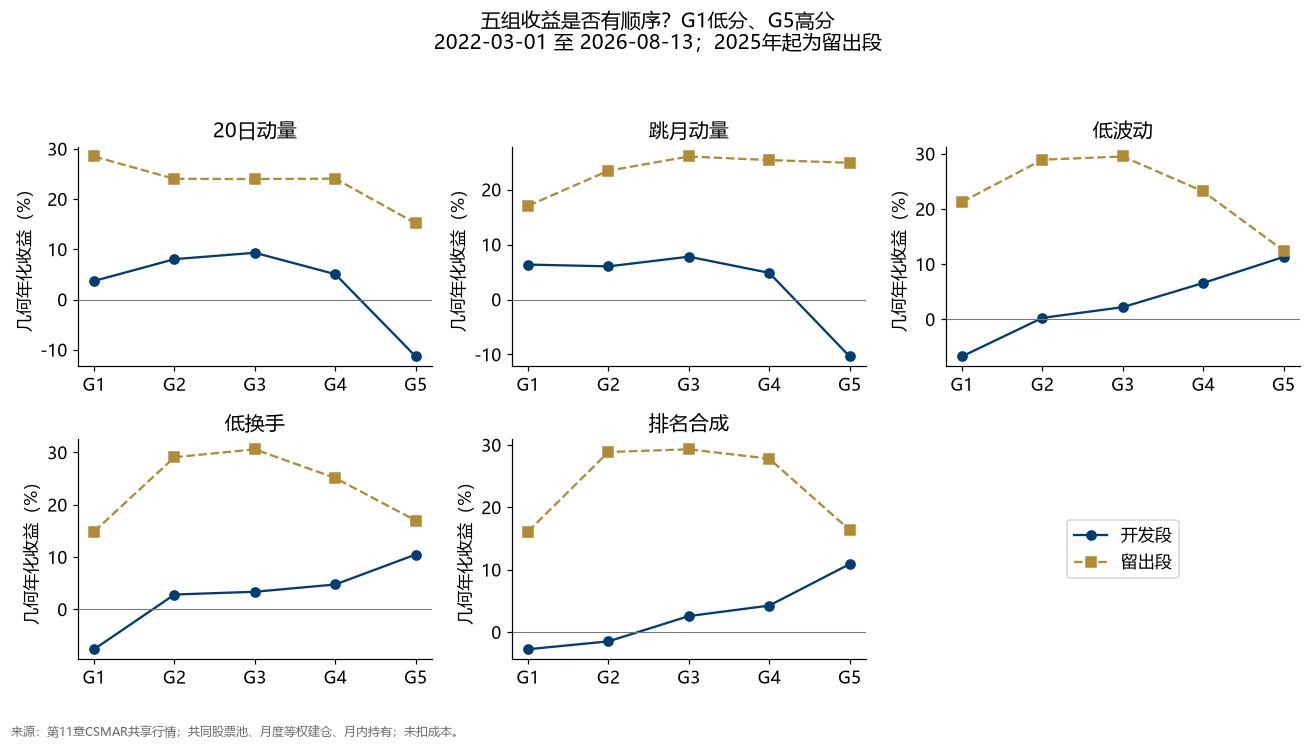

In [15]:
COLORS = {"20日动量": "#3F6788", "20日反转": "#A35B2A", "跳月动量": "#003D73",
          "低波动": "#658042", "低换手": "#B18B36", "排名合成": "#86567A", "同池基准": "#444444"}
PERIOD = f"{returns.index[0]:%Y-%m-%d} 至 {returns.index[-1]:%Y-%m-%d}"

def save_figure(fig, name):
    fig.text(0.01, 0.01, "来源：第11章CSMAR共享行情；共同股票池、月度等权建仓、月内持有；未扣成本。", fontsize=8, color="#666666")
    fig.tight_layout(rect=(0, 0.05, 1, 0.94))
    fig.savefig(FIGURES / f"{name}.png", dpi=170)
    plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 6.8))
for ax, (signal, label) in zip(axes.flat, SIGNALS.items()):
    for segment, style, color in [("开发段", "o-", "#003D73"), ("留出段", "s--", "#B18B36")]:
        values = summary.loc[segment].loc[[f"{signal}_{g}" for g in GROUPS], "几何年化收益"] * 100
        ax.plot(GROUPS, values, style, color=color, label=segment)
    ax.axhline(0, color="#777777", linewidth=0.7)
    ax.set(title=label, ylabel="几何年化收益（%）")
axes.flat[-1].axis("off")
axes.flat[-1].legend(*axes.flat[0].get_legend_handles_labels(), loc="center")
fig.suptitle("五组收益是否有顺序？G1低分、G5高分\n" + PERIOD + "；2025年起为留出段")
save_figure(fig, "group_profiles")

**本次输出：**开发段低波动、低换手与合成从G1到G5的年化收益依次提高；留出段三者的最高收益均出现在中间组，未延续单调关系。不能按图改选中间组再声称规则事先固定。

读取顺序：先看同一折线是否从G1到G5单调，再比较两个区段。`r20`的G1与G5分别对应反转与动量；`lowvol`的G5才是低波动端。折线不是置信区间，图中未做统计显著性检验。

### 8.1 短期动量、反转与较长动量

下面用相同起点、相同股票池的净值比较三种预设方向。灰色区段标记2025年开始的留出段；整段净值连续，但分段绩效各自重置起点。

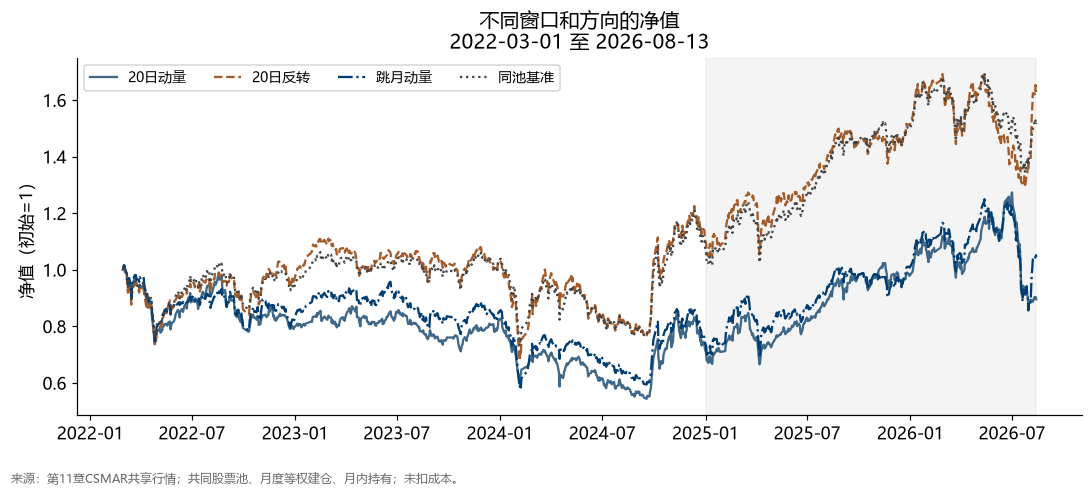

In [16]:
initial = pd.DataFrame(1.0, index=[first.execution_date], columns=selected_returns.columns)
wealth = pd.concat([initial, selected_returns.add(1).cumprod()])
fig, ax = plt.subplots(figsize=(10, 4.8))
for name, style in [("20日动量", "-"), ("20日反转", "--"), ("跳月动量", "-."), ("同池基准", ":")]:
    ax.plot(wealth.index, wealth[name], label=name, color=COLORS[name], linestyle=style)
ax.axvspan(SPLIT, wealth.index[-1], color="#777777", alpha=0.08)
ax.set(title="不同窗口和方向的净值\n" + PERIOD, ylabel="净值（初始=1）")
ax.legend(ncol=4, fontsize=9)
save_figure(fig, "momentum_nav")

**动量图的本次输出：**20日反转在开发段累计10.48%、留出段47.53%，20日动量分别为−28.07%、24.53%；较长跳月动量分别为−25.90%、41.14%。窗口与方向的历史表现不同，但这不是反转永远有效的证明。

### 8.2 低波动与低换手：收益、风险分别检查

下一图上半部分是净值，下半部分是相对历史峰值的回撤。低波动是过去信息，未来风险要看实际组合结果。低换手股票可能难以大额买卖；不能从历史净值推断交易容量。

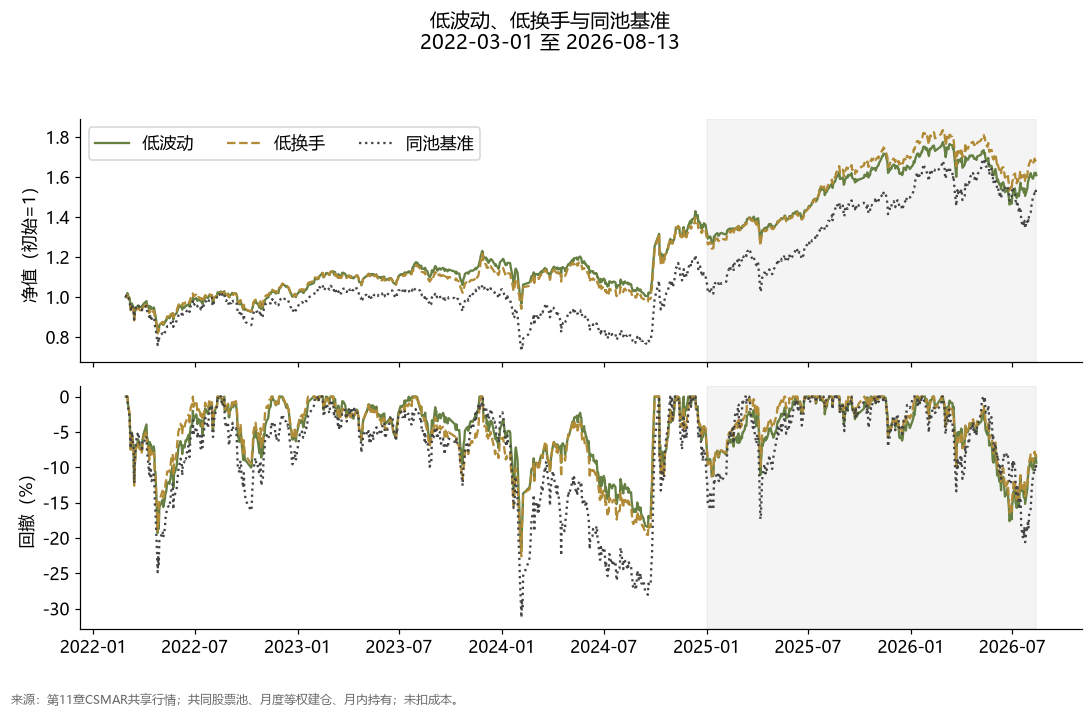

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
for name, style in [("低波动", "-"), ("低换手", "--"), ("同池基准", ":")]:
    axes[0].plot(wealth.index, wealth[name], label=name, color=COLORS[name], linestyle=style)
    dd = wealth[name] / wealth[name].cummax() - 1
    axes[1].plot(dd.index, dd * 100, color=COLORS[name], linestyle=style)
for ax in axes:
    ax.axvspan(SPLIT, wealth.index[-1], color="#777777", alpha=0.08)
axes[0].set(ylabel="净值（初始=1）")
axes[0].legend(ncol=3)
axes[1].set(ylabel="回撤（%）")
fig.suptitle("低波动、低换手与同池基准\n" + PERIOD)
save_figure(fig, "risk_turnover")

**风险图的本次输出：**留出段低波动、低换手的年化波动分别为16.52%、16.21%，均低于同池基准22.85%；累计收益19.97%、27.56%，也低于基准40.20%。较小波动并未伴随较高收益。

## 9. 合成与时间留出：固定规则后再检查

合成仅使用三个同日排名的等权平均，不训练参数。2025年之后每个月仍可使用截至当时已发生的价格形成信号，包括此前留出段历史；不可使用之后的收益来决定方向和权重。

留出区段可以报告全部预设策略。如果看完结果再换窗口、删指标或选冠军，新的版本须另找未查看数据，原留出段已经变成开发数据。

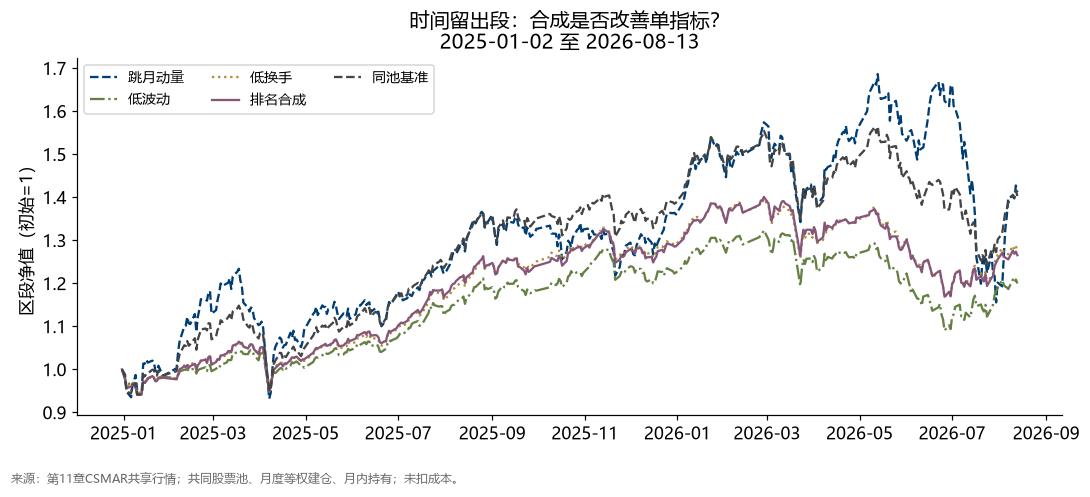

排名合成：累计26.53%，年化波动16.54%，最大回撤-16.55%
同池基准：累计40.20%，年化波动22.85%，最大回撤-20.60%


In [18]:
fig, ax = plt.subplots(figsize=(10, 4.8))
test = selected_returns.loc[selected_returns.index >= SPLIT, ["跳月动量", "低波动", "低换手", "排名合成", "同池基准"]]
anchor_date = calendar[calendar < test.index[0]][-1]
test_wealth = pd.concat([pd.DataFrame(1.0, index=[anchor_date], columns=test.columns), test.add(1).cumprod()])
for (name, series), style in zip(test_wealth.items(), ["--", "-.", ":", "-", "--"]):
    ax.plot(series.index, series, label=name, color=COLORS[name], linestyle=style)
ax.set(title=f"时间留出段：合成是否改善单指标？\n{test.index[0]:%Y-%m-%d} 至 {test.index[-1]:%Y-%m-%d}", ylabel="区段净值（初始=1）")
ax.legend(ncol=3, fontsize=9)
save_figure(fig, "holdout_combo")
test_stats = selected_summary.loc["留出段"]
for name in ["排名合成", "同池基准"]:
    s = test_stats.loc[name]
    print(f"{name}：累计{s['累计收益']:.2%}，年化波动{s['年化波动率']:.2%}，最大回撤{s['最大回撤']:.2%}")

**合成图的本次输出：**留出段合成累计26.53%，低于基准40.20%；最大回撤−16.55%，浅于基准−20.60%。合成体现了收益与风险的取舍，并未全面优于单指标。

### 9.1 排名相关与规模暴露

在每个信号日计算三个方向的Spearman排名相关，再对日期等权平均。它描述信号是否重复，不是未来收益相关性。规模图只取留出段组合对应的信号日，报告每期成分市值中位数的时间中位数；不能据此完成因果归因，下一章再引入因子模型。

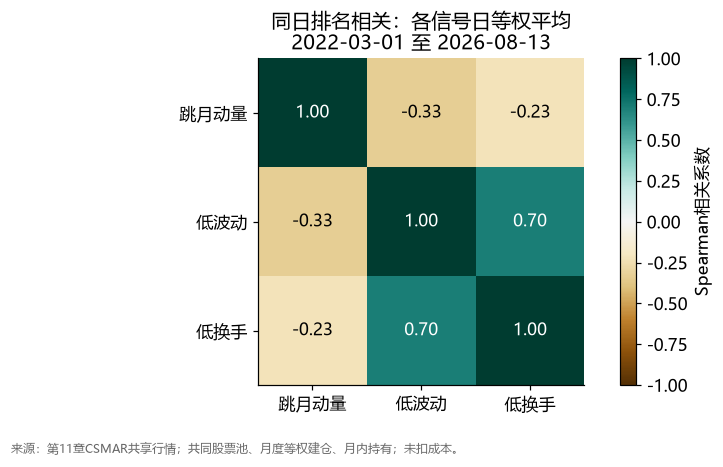

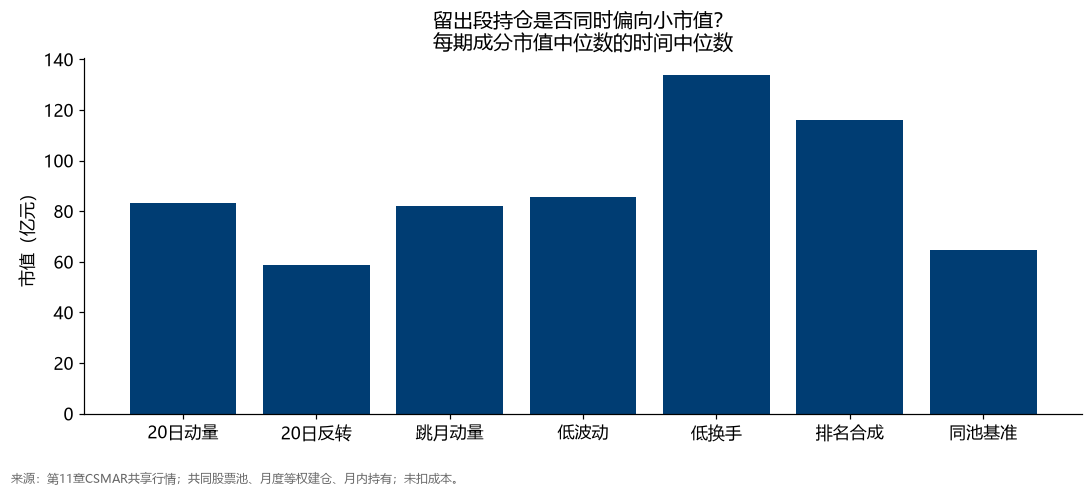

In [19]:
correlations = []
for date in schedule.signal_date:
    correlations.append(cross_section(date)[["mom", "lowvol", "lowturn"]].corr(method="spearman"))
rank_corr = sum(correlations) / len(correlations)
fig, ax = plt.subplots(figsize=(6.8, 4.5))
im = ax.imshow(rank_corr, vmin=-1, vmax=1, cmap="BrBG")
ax.set(xticks=range(3), yticks=range(3), xticklabels=["跳月动量", "低波动", "低换手"],
       yticklabels=["跳月动量", "低波动", "低换手"], title="同日排名相关：各信号日等权平均\n" + PERIOD)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{rank_corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(rank_corr.iloc[i, j]) > 0.6 else "black")
fig.colorbar(im, ax=ax, label="Spearman相关系数")
save_figure(fig, "rank_correlation")

# 2024年12月底信号对应2025年1月持仓，因此按持有期是否进入留出段筛选。
test_signals = schedule.loc[schedule.holding_end.ge(SPLIT), "signal_date"]
size_summary = composition.loc[composition.signal_date.isin(test_signals)].groupby("portfolio").median(numeric_only=True)
size_selected = size_summary.loc[list(PICKS.values()), "median_size_yi"]
size_selected.index = list(PICKS)
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(size_selected.index, size_selected, color="#003D73")
ax.set(ylabel="市值（亿元）", title="留出段持仓是否同时偏向小市值？\n每期成分市值中位数的时间中位数")
save_figure(fig, "size_exposure")

**相关与规模图的本次输出：**低波动与低换手的同日排名相关均值约0.70，说明两者信息有较多重叠；合成持仓的市值中位数高于同池基准。三项等权不等于三份互相独立的信息，也不能把全部收益差都归于量价信号。

## 10. 核验：时间、权重、窗口与收益能否对上？

不只检查代码运行。下面用首个真实持有期的“期末价格比 × 初始权重”独立复核连乘收益，并在截断历史上重算一次信号，确认未来价格没有进入当前评分。组数差、共同池、收益日期和初始回撤也需要核对。

In [20]:
assert (schedule.signal_date < schedule.execution_date).all()
assert (schedule.execution_date < schedule.holding_end).all()
assert sample_flow.common_pool.ge(5).all()
for signal in SIGNALS:
    counts = w0[[f"{signal}_{g}" for g in GROUPS]].gt(0).sum()
    assert counts.max() - counts.min() <= 1
manual = (prices.loc[first.holding_end, w0.index] / prices.loc[first.execution_date, w0.index]) @ w0
assert np.allclose(manual - 1, first_returns.add(1).prod() - 1)
cut = prices.loc[:first.signal_date]
assert np.allclose((cut.shift(SKIP) / cut.shift(LONG) - 1).iloc[-1].loc[example.index], example.mom)
cut_observed = observed.loc[:first.signal_date]
cut_vol = cut_observed.pct_change(fill_method=None).rolling(VOL, min_periods=MIN_VOL).std(ddof=1).iloc[-1] * np.sqrt(252)
assert np.allclose(cut_vol.loc[example.index], example.vol)
cut_turn = turn_daily.loc[:first.signal_date].rolling(TURN, min_periods=MIN_TURN).mean().iloc[-1]
assert np.allclose(cut_turn.loc[example.index], example.turn)
assert performance(pd.DataFrame({"x": [-0.1, 0.0]})).loc["x", "最大回撤"] == -0.1 or np.isclose(performance(pd.DataFrame({"x": [-0.1, 0.0]})).loc["x", "最大回撤"], -0.1)
print("通过：时间顺序、共同池、组数差、权重、收益覆盖、独立持有收益复核、历史截断和初始回撤。")

通过：时间顺序、共同池、组数差、权重、收益覆盖、独立持有收益复核、历史截断和初始回撤。


## 11. 导出：Notebook是计算入口

日收益每行是一天、每列是一个组合；`composition.csv`每行是某信号日的一个组合；`monthly_returns.csv`最后一行可能是不完整月份，附有标记。课件统计宏和两张结果表由本节自动生成，避免手抄结果。

下一章可从日收益出发，与同日期无风险利率和口径明确的A股因子对齐。本章组间差不是标准Mom、SMB或alpha，也未作统计显著性推断。

In [21]:
monthly = returns.add(1).groupby(returns.index.to_period("M")).prod().sub(1)
monthly["complete_month"] = monthly.index < calendar[-1].to_period("M")
exports = {"daily_returns": returns, "monthly_returns": monthly, "performance": summary,
           "selected_performance": selected_summary, "sample_flow": sample_flow,
           "schedule": schedule, "composition": composition, "rank_correlation": rank_corr,
           "first_signal": example[["r20", "mom", "vol", "turn", "combo"]]}
for name, table in exports.items():
    table.to_csv(TABLES / f"{name}.csv", encoding="utf-8-sig", index=True)
metadata = {"source": str(SOURCE.relative_to(ROOT)), "source_rows": source_rows,
    "data_start": str(calendar[0].date()), "data_end": str(calendar[-1].date()),
    "return_start": str(returns.index[0].date()), "return_end": str(returns.index[-1].date()),
    "rebalances": len(schedule), "return_days": len(returns), "split": str(SPLIT.date()),
    "windows": {"short": SHORT, "long": LONG, "skip": SKIP, "vol": VOL, "turn": TURN},
    "minimum_observations": {"long": MIN_LONG, "vol": MIN_VOL, "turn": MIN_TURN},
    "common_pool_min": int(sample_flow.common_pool.min()), "common_pool_max": int(sample_flow.common_pool.max())}
(CHAPTER / "outputs/analysis_summary.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
macros = {"DataStart": metadata["data_start"], "DataEnd": metadata["data_end"],
          "ReturnStart": metadata["return_start"], "ReturnEnd": metadata["return_end"],
          "Rebalances": str(len(schedule)), "ReturnDays": str(len(returns)),
          "FirstSignal": str(first.signal_date.date()), "FirstExecution": str(first.execution_date.date()),
          "PoolMin": str(metadata["common_pool_min"]), "PoolMax": str(metadata["common_pool_max"])}
for name, key in [("Combo", "排名合成"), ("Benchmark", "同池基准")]:
    macros[name + "TestReturn"] = f"{test_stats.loc[key, '累计收益'] * 100:.2f}"
    macros[name + "TestDrawdown"] = f"{test_stats.loc[key, '最大回撤'] * 100:.2f}"
(CHAPTER / "latex/analysis_numbers.tex").write_text("\n".join(
    rf"\newcommand{{\{key}}}{{{value}}}" for key, value in macros.items()) + "\n", encoding="utf-8")
for segment, filename in [("开发段", "development_table.tex"), ("留出段", "holdout_table.tex")]:
    table = (selected_summary.loc[segment] * 100).round(2)
    lines = [r"\begin{tabular}{lrrrr}", r"\toprule", r"组合 & 累计收益 & 年化收益 & 年化波动 & 最大回撤\\", r"\midrule"]
    for name, row in table.iterrows():
        lines.append(name + " & " + " & ".join(f"{x:.2f}" for x in row) + r"\\")
    lines += [r"\bottomrule", r"\end{tabular}"]
    (CHAPTER / "latex" / filename).write_text("\n".join(lines) + "\n", encoding="utf-8")
example_table = example[["r20", "mom", "vol", "turn", "combo"]].head(4)
lines = [r"\begin{tabular}{lrrrrr}", r"\toprule", r"代码 & 20日收益 & 跳月动量 & 年化波动 & 日均换手 & 合成分\\", r"\midrule"]
for stock, row in example_table.iterrows():
    lines.append(stock + " & " + " & ".join(f"{v*100:.2f}" for v in row.iloc[:4]) + f" & {row.iloc[4]:.3f}" + r"\\")
lines += [r"\bottomrule", r"\end{tabular}"]
(CHAPTER / "latex/signal_example.tex").write_text("\n".join(lines) + "\n", encoding="utf-8")
print("已导出9张表、统计宏与3张课件表；行情输入未改写。")

已导出9张表、统计宏与3张课件表；行情输入未改写。


## 12. 课堂练习

1. 一只股票在 $s-120,s-20,s$ 的价格依次是50、60、54。计算两个窗口收益，并说明它在两个排序中的位置为什么可能不同。
2. 成交200万股、收盘8元、流通市值16万千元，日换手率是多少？若忘记千元换元，会差多少倍？
3. 为什么不能先求三项原始指标的平均？为什么低波动要取负号再排名？
4. 对照五组图：开发段与留出段是否都单调？分别报告合成与基准的累计收益和最大回撤，不按结果更换策略。
5. 将较长动量改成252日并跳过21日，会怎样改变预热期和可选样本？先写预期与规则，再运行扩展实验；原留出段不得再称新版本的未查看检验。
6. 低换手净值较好是否证明能容纳更多资金？还需要哪些数据与约束？

<details>
<summary>参考答案（先独立完成）</summary>

1. 较长窗口20%，最近窗口−10%；与别的股票比较的窗口不同，次序可以相反。
2. 10%；忘乘1000会放大1000倍。必须用未复权收盘价。
3. 波动、换手与收益的量纲和分布不同；先统一“高分方向”，再在同一横截面排名。排名消除尺度，不能消除相关性或保证收益。
4. 使用第8节两段结果表与第9节合成图；图不是显著性检验，局部不单调或分段差异都应保留。
5. 更长预热会推迟首次建仓，近期上市股票可能被排除；还应同步调整最低历史观测要求。252/21只是交易日近似，不等于逐月精确的经典动量。
6. 不能。需要成交额、买卖价差、盘口深度、涨跌停/停牌约束、冲击成本以及下单金额占成交量比例。个股低换手与组合低调仓率是不同概念。

</details>

### 继续到第14章

“收益较高”之后还要问：承担了什么系统风险？因子模型能解释多少？剩余alpha对样本、模型和成本有多敏感？保存本章组合日收益，并保留共同池、收益口径和时间切分记录。